In [6]:
import tensorflow as ts
import warnings
warnings.filterwarnings("ignore")

I0000 00:00:1779707061.899483    5302 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779707061.968603    5302 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779707064.300393    5302 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [7]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [8]:
train_images[0].shape

(28, 28)

In [9]:
from tensorflow.keras import models
from tensorflow.keras import layers
network = models.Sequential([
        layers.Dense(512, activation='relu'),
       layers.Dense(10, activation='softmax')
])


In [10]:
network.compile(optimizer='rmsprop',loss='categorical_crossentropy', metrics=['accuracy'])

E0000 00:00:1779707066.963217    5302 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [11]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype('float32') / 255

In [12]:
from tensorflow.keras.utils import to_categorical
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [13]:
class StopTrainingAtAccuracy(ts.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('accuracy') > 0.90:
            print("\nReached 95% accuracy, stopping training!")
            self.model.stop_training = True

In [14]:
# callbackfunc = StopTrainingAtAccuracy()
network.fit(train_images, train_labels, epochs=5)

Epoch 1/5


W0000 00:00:1779707067.932754    5302 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9403 - loss: 0.2014
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9740 - loss: 0.0864
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9823 - loss: 0.0598
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9869 - loss: 0.0446
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9898 - loss: 0.0352


In [15]:

network.evaluate(test_images,test_labels)

W0000 00:00:1779707146.049034    5302 cpu_allocator_impl.cc:82] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9786 - loss: 0.0815


[0.08151926845312119, 0.978600025177002]

TypeError: Invalid shape (784,) for image data

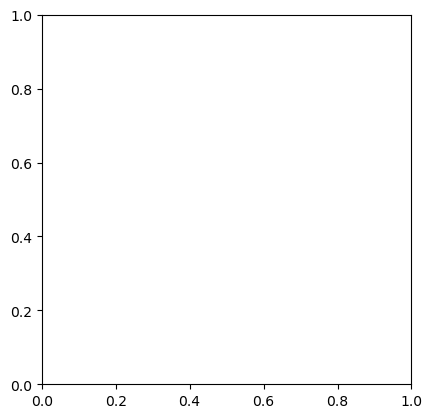

In [16]:
digit = train_images[4]
label = train_labels[4]
import matplotlib.pyplot as plt
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()
print(label)

In [17]:
inp_num = 8
inp = test_images[inp_num].reshape(1,784)

In [18]:
print(test_labels[inp_num].argmax())

5


In [19]:
network.predict(inp).argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


np.int64(5)

In [20]:
from PIL import Image
import numpy as np


original_image = Image.open('testing_images/2(white).png')
grey_scale = original_image.convert('L')

grey_scale = np.array(grey_scale)/255
new_arr = np.where(grey_scale ==1, 0,grey_scale)
grey_scale = new_arr.reshape(1,784)
 # Output will be (height, width)


In [21]:
original_image

In [22]:
new_arr

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [23]:
network.predict(grey_scale).argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


np.int64(3)